### Phase-based encoding in pairwise neural interactions

This notebook reproduces **Figure 1** by simulating two coupled Kuramoto oscillators and quantifying how phase differences encode coupling strength.

Workflow:
1. Configure environment and imports.
2. Simulate trial-wise coupled dynamics.
3. Compute Hilbert / wavelet representations.
4. Estimate coherence and mutual information.
5. Build and save the multi-panel figure.

#### 1) Environment check

This section confirms which Python interpreter is used by the notebook kernel and adds the project root to the Python path so local modules under `src/` can be imported reliably.

In [1]:
# Display the Python executable used by the current notebook kernel.
import os
import sys; print(sys.executable)

/usr/bin/python3


In [2]:
# Add the project root so local modules (e.g., src.models) are importable.
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

#### 2) Imports and dependencies

This cell imports scientific Python libraries, information-theoretic tools from HOI/Frites, and the local Kuramoto simulator used for the synthetic data.

In [3]:
# Import analysis libraries for simulation, time-frequency decomposition, and information metrics.
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy
import xarray as xr
from frites.core import copnorm_nd
from hoi.core import get_mi
from mne.time_frequency import tfr_array_morlet, tfr_array_multitaper
from tqdm import tqdm

from src.models import simulate_kuramoto

/home/INT/brovelli.a/.local/lib/python3.10/site-packages/tqdm-4.67.1-py3.10.egg/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import jax
# Check if JAX is using the GPU backend and print the available devices and default backend.
print(jax.devices())   
# This will show the list of devices JAX is using (e.g., GPU, CPU) and confirm the default backend.       
print(jax.default_backend()) 

[CpuDevice(id=0)]
cpu


In [5]:
# Configure consistent font sizes for publication-style figure panels.
SMALL_SIZE = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

#### 3) Simulation setup

Define oscillator parameters, trial count, and a transient Gaussian-shaped coupling profile whose peak amplitude varies across trials.

In [6]:
# Define model parameters and timeline for Kuramoto simulations.
dt = 0.001  # Integration time-step
fs = 1 / dt
f = 40  # Natural frequency
beta = 2.5  # Noise variance
A = np.array([[0, 1], [0, 0]]).T
ntrials = 1000
time = np.arange(-0.5, 1, 1 / fs)  # Time array
T = time.shape[0]

In [7]:
# Build a Gaussian temporal coupling profile and trial-specific coupling strengths.
s = 8 / (2 * np.pi * f)
# Define the time window for coupling (0 to 0.4 seconds) and create a Gaussian profile centered in that window.
time_start = 0
time_end = 0.4
timestim = time[(time > time_start) & (time < time_end)] - (time_end - time_start) / 2
ind = np.where((time > time_start) & (time < time_end))[0]
gaussian = np.exp(-(timestim**2) / (2 * s**2))
coupling = np.zeros_like(time)
coupling[ind] = gaussian
# Coupling strength array (linearly spaced from 1 to 100)
CS = np.linspace(1, 100, ntrials)
seeds = np.random.randint(0, 100000, ntrials)

In [17]:
# If decimation is applied, the resulting time series will have fewer time points, so we need to adjust the array shape accordingly.
decim = 1
T_decim = T // decim  # time steps after decimation in msec

# Pre-allocate numpy array so each trial's JAX device buffer is freed immediately
# instead of all 1000 XLA buffers accumulating in a Python list (OOM at ~880 trials).
data = np.empty((ntrials, 2, T_decim), dtype=np.float64)

for trial in tqdm(range(ntrials)):
    result = simulate_kuramoto(
        10 * A,
        np.zeros_like(A),
        coupling * CS[trial],
        f,
        fs,
        beta,
        T,
        seed=seeds[trial],
        decim=decim,
    )
    # np.asarray() copies the JAX array to numpy and releases the XLA device buffer.
    data[trial] = np.asarray(result)


100%|██████████| 1000/1000 [00:05<00:00, 177.16it/s]


In [15]:
T

1500

#### 4) Time-frequency transforms and information metrics

Compute the analytic signal, extract wavelet coefficients, estimate coherence, and quantify mutual information between phase differences and coupling labels.

In [ ]:

# Compute the analytic signal with the Hilbert transform.
# data is already (ntrials, 2, T_decim); np.stack is a no-op here but kept for clarity.
time_decim = time[::decim]  # decimated time axis, aligned with data
h = scipy.signal.hilbert(data.real, axis=2)


In [ ]:
# Compute complex Morlet wavelet coefficients across frequencies.
freqs = np.linspace(0.1, 80, 50)
# Decimate the time-frequency representation to reduce memory usage and speed up subsequent analyses.
decim = 10
# TF decomposition with Morlet wavelets, decimating the output to reduce memory usage and speed up subsequent analyses.
W = tfr_array_morlet(
    data,
    fs / 1,
    freqs,
    n_cycles=freqs / 4,
    decim=decim,
    output="complex",
    verbose=None,
)

[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    2.6s finished


In [11]:
# Estimate time-frequency coherence from cross- and auto-spectra.
Sxy = (W[:, 0] * np.conj(W[:, 1])).mean(0)
Sxx = (W[:, 0] * np.conj(W[:, 0])).mean(0)
Syy = (W[:, 1] * np.conj(W[:, 1])).mean(0)

# Coherence is theoretically bounded in [0, 1].
# Use real autospectra, then remove numerical artifacts before plotting.
coh = np.abs(Sxy) ** 2 / (np.real(Sxx) * np.real(Syy))

In [12]:
# Compute mutual information between phase difference and coupling strength across time-frequency bins.
# Use Gaussian-copula MI with internal copula normalization.
mi_fcn = get_mi("gc")

# Vectorize over time, then frequency.
# x / y are expected as (n_features, n_samples)
mi_fcn_time = jax.vmap(mi_fcn, in_axes=(2, 2, None, None))
mi_fcn_time_frequency = jax.vmap(mi_fcn_time, in_axes=(2, 2, None, None))

z = W[:, 0] * np.conj(W[:, 1])

# Phase difference (wrapped to [-pi, pi])
dphi = np.angle(z)
dphi = np.abs((dphi + np.pi) % (2 * np.pi) - np.pi)

# dphi = copnorm_nd(dphi, axis=0)

labels = np.tile(
    np.expand_dims(np.arange(0, ntrials), (1, 2)), (z.shape[1], z.shape[2])
)

# labels = copnorm_nd(labels, axis=0)

# Add features dimension: (1, trials, freqs, times) to match vmap axis layout
dphi = dphi[np.newaxis, :]
labels = labels[np.newaxis, :]

MI_PHI_gc = mi_fcn_time_frequency(dphi, labels, False, True)


In [13]:
from hoi.utils import digitize

mi_fcn = get_mi("binning", base=2)

# entropy_fcn is already bound inside mi_fcn; the returned function takes only (x, y)
mi_fcn_time = jax.vmap(mi_fcn, in_axes=(2, 2))
mi_fcn_time_frequency = jax.vmap(mi_fcn_time, in_axes=(2, 2))

z = W[:, 0] * np.conj(W[:, 1])

# Phase difference (wrapped to [-pi, pi])
dphi = np.angle(z)
dphi = np.abs((dphi + np.pi) % (2 * np.pi) - np.pi)

# Pre-discretize before passing to the binning estimator
dphi = digitize(dphi, n_bins=6)

labels = np.tile(
    np.expand_dims(np.arange(0, ntrials), (1, 2)), (z.shape[1], z.shape[2])
)
labels = digitize(labels, n_bins=6)

# Add features dimension: (1, trials, freqs, times) to match vmap axis layout
dphi = dphi[np.newaxis, :]
labels = labels[np.newaxis, :]

MI_PHI_bin = mi_fcn_time_frequency(dphi, labels)

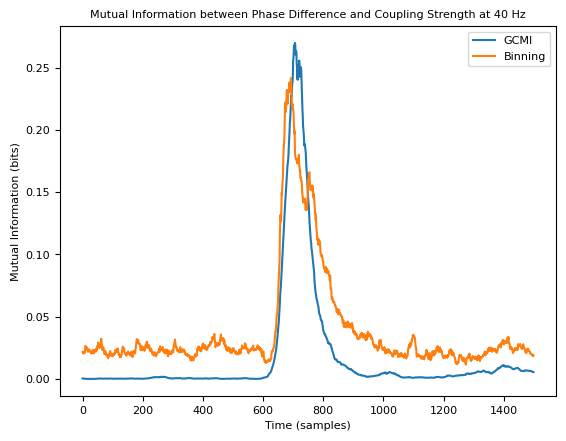

In [14]:
# Plot MI_PHI_gc and MI_PHI_bin one on top of the other for comparison.
plt.plot(MI_PHI_gc[25, :], label="GCMI")
plt.plot(MI_PHI_bin[25, :], label="Binning")
plt.xlabel("Time (samples)")
plt.ylabel("Mutual Information (bits)")
plt.title("Mutual Information between Phase Difference and Coupling Strength at 40 Hz")
plt.legend()

#### 5) Figure assembly and export

Create a multi-panel layout, draw simulation/metric panels, annotate them, and export the final figure to PDF.

In [ ]:

# Build, annotate, and export the multi-panel figure for the simulated analysis.
import plot
from PIL import Image

fig = plt.figure(figsize=(6.0, 4.5), dpi=600)

gs1 = fig.add_gridspec(nrows=1, ncols=1, left=0.1, right=0.4, bottom=0.7, top=0.95)
gs2 = fig.add_gridspec(
    nrows=3, ncols=1, left=0.1, right=0.4, bottom=0.08, top=0.65, hspace=0.4
)
gs3 = fig.add_gridspec(
    nrows=2, ncols=1, left=0.55, right=0.92, bottom=0.08, top=0.95, hspace=0.4
)

# Panel A
ax1 = plt.subplot(gs1[0])

# Panel B
ax2 = plt.subplot(gs2[0])
ax3 = plt.subplot(gs2[1])
ax5 = plt.subplot(gs2[2])

# Panels C-E
ax6 = plt.subplot(gs3[0])
ax7 = plt.subplot(gs3[1])


###################################### DRAWING ######################################

# PANEL A
plt.sca(ax1)
im = Image.open("../figures/kuramoto_cartoon.png")
plt.imshow(im)
plt.axis("off")

# PANEL B-E
plt.sca(ax2)
[plt.plot(time, coupling * i) for i in [1, 2, 3]]
[ax2.spines[key].set_visible(False) for key in ["top", "right", "bottom"]]
plt.legend(["Trial 1", "Trial 2", "Trial 3"], frameon=False)
plt.xticks([])
plt.ylabel("g")
plt.xlim(0, 0.5)

plt.sca(ax3)
# data[250] shape: (2, T_decim) — use time_decim to match decimated time axis
plt.plot(time_decim, data[250].T[:, 0], c="r", lw=0.8)
plt.xlim(0, 0.5)
plt.xticks([])
[ax3.spines[key].set_visible(False) for key in ["top", "right", "bottom"]]
plt.ylabel("Node $i$")

plt.plot(time_decim, data[250].T[:, 1], c="g", lw=0.8)
plt.xlim(0, 0.5)
plt.xticks([])
[ax5.spines[key].set_visible(False) for key in ["top", "right", "bottom"]]
plt.ylabel("time-series")

plt.sca(ax5)
plt.plot(time_decim, np.abs(h.mean(1)).mean(0))
[ax5.spines[key].set_visible(False) for key in ["top", "right"]]
plt.xlabel("Time [s]")
plt.ylabel("KOP")
plt.xlim(0, 0.5)

# PANEL F
plt.sca(ax6)
plt.imshow(
    coh.real,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[-0.5, 1, 0.1, 80],
    vmin=0,
)
cbar = plt.colorbar()
cbar.set_label("Coherence", rotation=270, labelpad=15)
plt.xlabel("")
plt.ylabel("Frequency [Hz]")

# PANEL G
plt.sca(ax7)
mi_phi_plot = np.asarray(MI_PHI_gc).squeeze()
mi_vmax = np.nanpercentile(mi_phi_plot, 99)
if not np.isfinite(mi_vmax) or mi_vmax <= 0:
    mi_vmax = 1e-12

plt.imshow(
    mi_phi_plot,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    extent=[-0.5, 1, 0.1, 80],
    vmin=0,
    vmax=mi_vmax,
)
cbar = plt.colorbar()
cbar.set_label(r"I($\Delta\theta$; Y) [bits]", rotation=270, labelpad=15)
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")

# Background, labels, and annotations
bg = plot.Background(visible=False)
plot.add_panel_letters(
    fig,
    axes=[ax1, ax2, ax3, ax5, ax6, ax7],
    fontsize=MEDIUM_SIZE,
    xpos=[-0.3] * 6,
    ypos=[1.1] * 5 + [0.95] * 2,
)

plt.savefig("../figures/Figure1.pdf")


### Figure caption and interpretation

Figure 1: Phase-based encoding in pairwise neural interactions. (A) Simulation of two Kuramoto oscillators (see Eq. 13; using identical parameters for both nodes: ω = 2π40 Hz, η = 2.5, and coupling strength C12 = 10) coupled via an undirected edge.

The time series of the simulated dynamical system are represented by their instantaneous phases θ(t) (depicted by green and red arrows in the unit circle). The coupling strength g(t) is unidirectional from Xi to Xj.

(B) The coupling strength g(t) between the two nodes was time-modulated such that it was transiently non-zero from 0.1 to 0.3 s, following g(t) = 8Y/(2πf), where Y was the maximum coupling amplitude, increased from 1 to 100 across trials (n = 1000).

(C) Time series of the simulated Kuramoto nodes for the trial with the strongest coupling. (D) Kuramoto order parameter (KOP) time series averaged across trials.

(E) Time-frequency coherence spectrogram between the two nodes computed using wavelet decomposition (n_cycles = fc / 4; for fc ∈ [0.1, 80] Hz). (F) Mutual information between the phase difference of the two nodes (computed from the wavelet coefficients according to Eq. 10) and the coupling amplitudes Y.